# Introduction : Generating Biomass capacity cost curves for EU using the ENSPRESO database


Data for this study are a combination of EU biomass potentials and costs at country level from the ENSPRESO database (Ruiz et al.,2019, 10.1016/j.esr.2019.100379), completed with excel data pretreatment. GHG emission factors  of bioenergy crops at country level are derived from the underlying study from the JRC : "The JRC-EU-TIMES model: bioenergy potentials for EU and neighbouring countries."(https://data.europa.eu/doi/10.2790/39014). GHG emission factors of residues are derived from Ecoinvent 3.9 LCA values.

#### Package imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import math
import numpy as np

import os
os.environ["AMPL_LICFILE"] = r"C:\Users\ED281169\AMPL\ampl.lic"

from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\ED281169\Documents\EnergyScope\EnergyScopeFR_Biomass_supply_curves")
os.chdir(PROJECT_ROOT)

os.chdir(PROJECT_ROOT)




#### Database loading, scenario selection, colors

In [2]:
excel_file = "ENSPRESO_supply_curves_NUTS0.xlsx"

sheet = "HIGH 2050 NUTS0" 

df = pd.read_excel(excel_file,sheet_name=sheet)

colors = {
"SOLID": "saddlebrown",
"WET": "green",
"STARCH": "purple",
"OIL": "gold",
"RESIDUE":"grey",
"ENERGY CROP": "blue"
}

### Aggregated supply-cost curve (EU 28)


Biomass categories (SOLID, WET, STARCH, OIL) are differenciated by colors and sorted by increasing production cost.

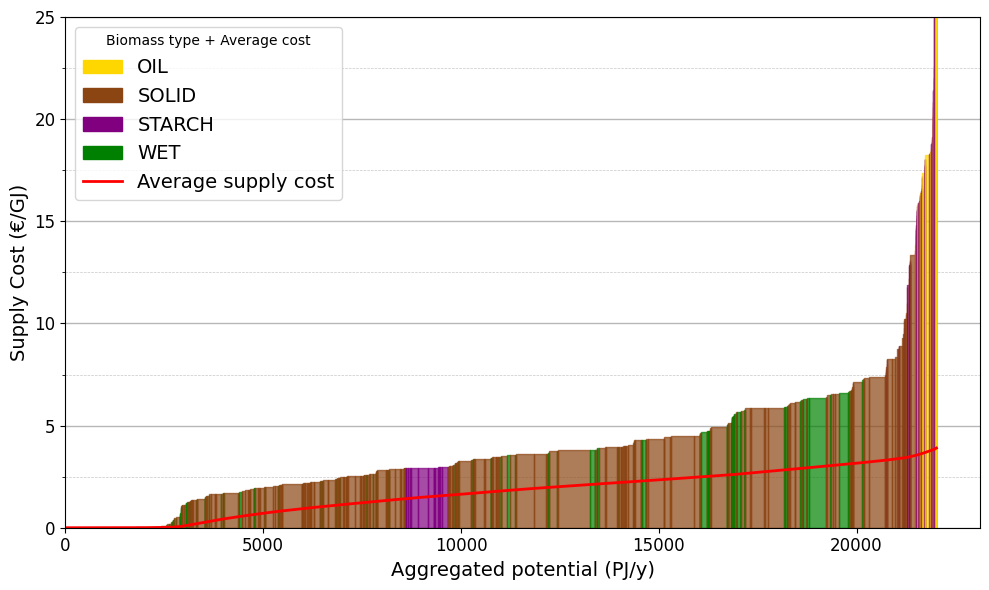

In [3]:
df = df.sort_values(by=["Cost (€/GJ)", "Category"]).reset_index(drop=True)
df["Q_start"] = df["Potential (PJ)"].cumsum().shift(fill_value=0)
df["Q_end"] = df["Potential (PJ)"].cumsum()


# --- 5) Tracer la courbe d'offre avec rectangles pleins + courbe du coût moyen ---
fig, ax = plt.subplots(figsize=(10, 6))

# Rectangles
for _, row in df.iterrows():
    ax.fill_betweenx(y=[0, row["Cost (€/GJ)"]],
                     x1=row["Q_start"], x2=row["Q_end"],
                     color=colors.get(row["Category"], "grey"), alpha=0.7, step="post")

# --- Calcul du coût moyen cumulé ---
df["cost_x_potential"] = df["Cost (€/GJ)"] * df["Potential (PJ)"]
df["cumulative_cost"] = df["cost_x_potential"].cumsum()
df["cumulative_potential"] = df["Potential (PJ)"].cumsum()
df["average_cost"] = df["cumulative_cost"] / df["cumulative_potential"]

# Tracer la courbe de coût moyen (ligne rouge épaisse)
ax.plot(df["cumulative_potential"], df["average_cost"],
        color="red", linewidth=2, label="Average supply cost")

# --- Placer la grille en arrière-plan ---
ax.set_axisbelow(True)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
ax.grid(which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
ax.grid(which='major', axis='y', linestyle='-', linewidth=1, alpha=0.9)

# --- Légende mise à jour ---
patches = [mpatches.Patch(color=colors[t], label=t) for t in df['Category'].dropna().astype(str).unique()]
legend_handles = patches + [plt.Line2D([0], [0], color='red', lw=2, label='Average supply cost')]
ax.legend(handles=legend_handles, title='Biomass type + Average cost',fontsize=14)

# --- Limites pour partir de (0,0) ---
ax.set_xlim(0, df['Q_end'].max() * 1.05)
ax.set_ylim(0, 25)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Aggregated potential (PJ/y)", fontsize=14)
ax.set_ylabel("Supply Cost (€/GJ)", fontsize=14)
#ax.set_title("Biomass supply cost curve - EU 28 (cumulative)")
plt.tight_layout()
plt.show()

### Aggregated GHG curve (EU 28): 


Biomass categories (SOLID, WET, STARCH, OIL) are differenciated by colors

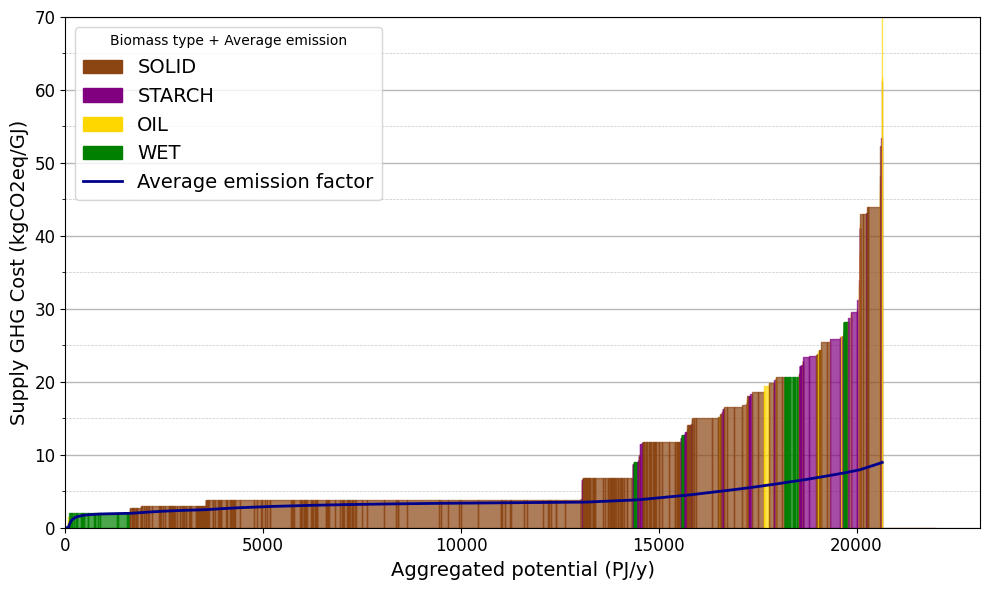

In [4]:
df = df.sort_values(by=["GHG (kgCO2eq/GJ)", "Category"]).reset_index(drop=True)
df["Q_start"] = df["Potential (PJ)"].cumsum().shift(fill_value=0)
df["Q_end"] = df["Potential (PJ)"].cumsum()

fig, ax = plt.subplots(figsize=(10, 6))

# --- Rectangles pleins ---
for _, row in df.iterrows():
    ax.fill_betweenx(y=[0, row["GHG (kgCO2eq/GJ)"]],
                     x1=row["Q_start"], x2=row["Q_end"],
                     color=colors.get(row["Category"], "grey"), alpha=0.7, step="post")

# --- Calcul du facteur d'émission moyen cumulatif ---
df["emission_x_potential"] = df["GHG (kgCO2eq/GJ)"] * df["Potential (PJ)"]
df["cumulative_emissions"] = df["emission_x_potential"].cumsum()
df["cumulative_potential"] = df["Potential (PJ)"].cumsum()
df["average_emission"] = df["cumulative_emissions"] / df["cumulative_potential"]

# Tracer la courbe de facteur d'émission moyen (ligne bleu foncé)
ax.plot(df["cumulative_potential"], df["average_emission"],
        color="darkblue", linewidth=2, label="Average emission factor")

# --- Grille et axes ---
ax.set_axisbelow(True)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
ax.grid(which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
ax.grid(which='major', axis='y', linestyle='-', linewidth=1, alpha=0.9)

# --- Légende mise à jour ---
patches = [mpatches.Patch(color=colors[t], label=t) for t in df['Category'].dropna().astype(str).unique()]
legend_handles = patches + [plt.Line2D([0], [0], color='darkblue', lw=2, label='Average emission factor')]
ax.legend(handles=legend_handles, title='Biomass type + Average emission', fontsize=14)

# --- Limites cohérentes ---
ax.set_xlim(left=0)
ax.set_ylim(0, 70)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Aggregated potential (PJ/y)", fontsize=14)
ax.set_ylabel("Supply GHG Cost (kgCO2eq/GJ)", fontsize=14)
#ax.set_title("Biomass GHG supply cost curve - EU 28 (cumulative)")
plt.tight_layout()
plt.show()

### Supply-cost curves (EU 28) by biomass category

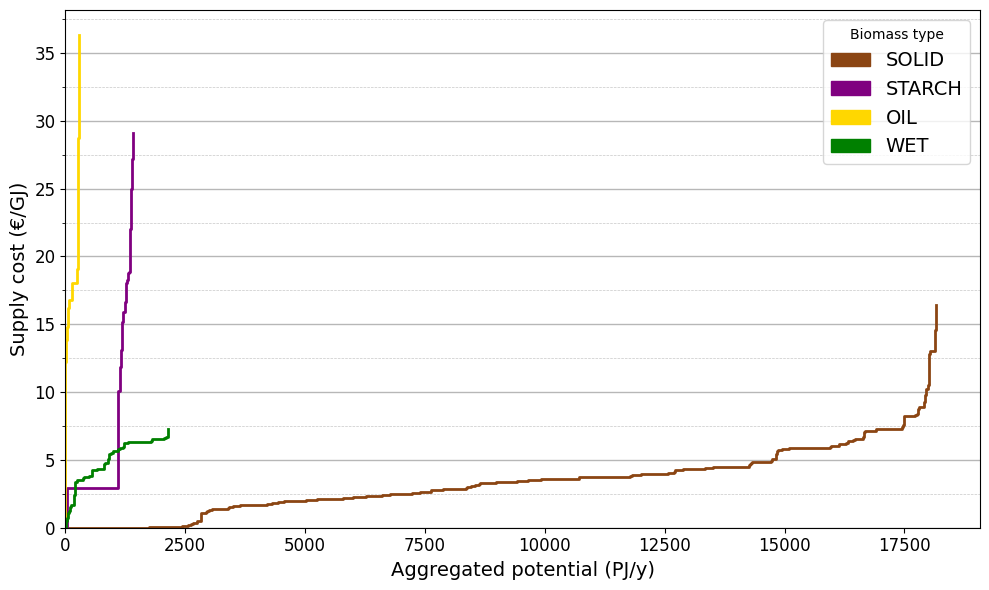

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

# --- Placer la grille en arrière-plan ---
ax.set_axisbelow(True)

# --- Lignes secondaires sur l'axe Y ---
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))  # 2 lignes secondaires par intervalle majeur
ax.grid(which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

# --- Lignes majeures visibles plus épaisses ---
ax.grid(which='major', axis='y', linestyle='-', linewidth=1, alpha=0.9)

# --- Lignes cumulatives par type ---
for t in df['Category'].unique():
    df_t = df[df['Category'] == t].sort_values('Cost (€/GJ)')
    q_cum = df_t['Potential (PJ)'].cumsum()
    prix = df_t['Cost (€/GJ)']
    
    # Ajouter un point initial (0,0) pour chaque type
    q_points = [0] + q_cum.tolist()
    prix_points = [0] + prix.tolist()
    
    ax.step(q_points, prix_points, where='post', label=f"{t} cumulative", linewidth=2, color=colors.get(t, 'grey'))

# --- Légende ---
patches = [mpatches.Patch(color=colors[t], label=t) for t in df['Category'].dropna().astype(str).unique()]
ax.legend(handles=patches, title='Biomass type', fontsize=14)

# --- Axes et titre ---
ax.set_xlabel('Aggregated potential (PJ/y)', fontsize=14)
ax.set_ylabel('Supply cost (€/GJ)', fontsize=14)
#ax.set_title("Biomass supply cost curves by biomass type - EU 28 (cumulative)")
ax.tick_params(axis='both', labelsize=12)
# --- Limites pour partir de (0,0) ---
ax.set_xlim(left=0)
ax.set_ylim(0, df['Cost (€/GJ)'].max() * 1.05)

plt.tight_layout()
plt.show()

GHG curves (EU 28) by biomass category

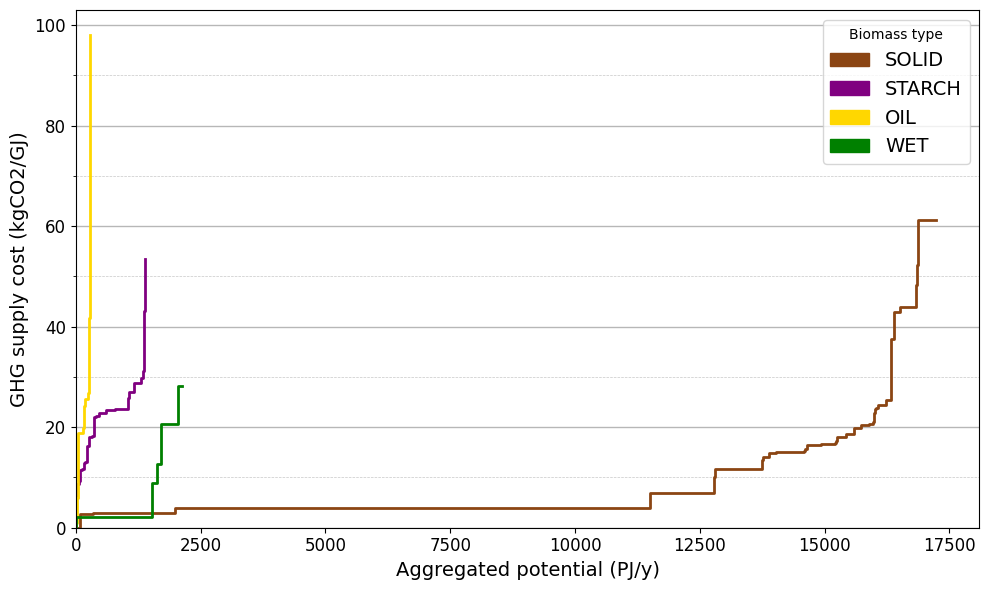

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

# --- Placer la grille en arrière-plan ---
ax.set_axisbelow(True)

# --- Lignes secondaires sur l'axe Y ---
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))  # 2 lignes secondaires par intervalle majeur
ax.grid(which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

# --- Lignes majeures visibles plus épaisses ---
ax.grid(which='major', axis='y', linestyle='-', linewidth=1, alpha=0.9)

# --- Lignes cumulatives par type ---
for t in df['Category'].unique():
    df_t = df[df['Category'] == t].sort_values('GHG (kgCO2eq/GJ)')
    q_cum = df_t['Potential (PJ)'].cumsum()
    emissions = df_t['GHG (kgCO2eq/GJ)']
    
    # Ajouter un point initial (0,0) pour chaque type
    q_points = [0] + q_cum.tolist()
    emissions_points = [0] + emissions.tolist()
    
    ax.step(q_points, emissions_points, where='post', label=f"{t} cumulative", linewidth=2, color=colors.get(t, 'grey'))

# --- Légende ---
patches = [mpatches.Patch(color=colors[t], label=t) for t in df['Category'].dropna().astype(str).unique()]
ax.legend(handles=patches, title='Biomass type', fontsize=14)

# --- Axes et titre ---
ax.set_xlabel('Aggregated potential (PJ/y)', fontsize=14)
ax.set_ylabel('GHG supply cost (kgCO2/GJ)', fontsize=14)
#ax.set_title("Biomass GHG supply cost curves by biomass type - EU 28 (cumulative)")
ax.tick_params(axis='both', labelsize=12)
# --- Limites pour partir de (0,0) ---
ax.set_xlim(left=0)
ax.set_ylim(0, df['GHG (kgCO2eq/GJ)'].max() * 1.05)

plt.tight_layout()
plt.show()

### Supply-cost curves by biomass category and country

In [7]:
feuilles_pays = ['FR','DE','PL','ES','SE','RO','IT','FI','UK','HU','AT']

# Lecture unique (si le fichier a plusieurs feuilles, précise sheet_name)
df_all = pd.read_excel(excel_file, sheet_name=sheet, header=0)

df_all.columns = df_all.columns.str.strip()

country_col = 'NUTS0'
cost_col = 'Cost (€/GJ)'
qty_col = 'Potential (PJ)'
type_col = 'Category'



# Nettoyage
df_all[cost_col] = pd.to_numeric(df_all[cost_col], errors='coerce')
df_all[qty_col] = pd.to_numeric(df_all[qty_col], errors='coerce').fillna(0)

# Filtrer les pays voulus
df_all = df_all[df_all[country_col].isin(feuilles_pays)]

# --- Détection colonnes et calcul Prix_max & Q_max globaux ---
valid_sheets = {}
Prix_max = 0
Q_max = 0

for code, df_c in df_all.groupby(country_col):
    df_c = df_c.copy()
    total_potential = df_c[qty_col].sum()

    valid_sheets[code] = {
        'df': df_c,
        'cost_col': cost_col,
        'qty_col': qty_col,
        'type_col': type_col if type_col else None,
        'total_potential': total_potential
    }

    Prix_max = max(Prix_max, df_c[cost_col].max())
    Q_max = max(Q_max, total_potential)

# --- TRI par potentiel décroissant ---
valid_sheets = dict(sorted(valid_sheets.items(), key=lambda x: x[1]['total_potential'], reverse=True))

n_pays = len(valid_sheets)
ncols = 3
nrows = math.ceil(n_pays / ncols)


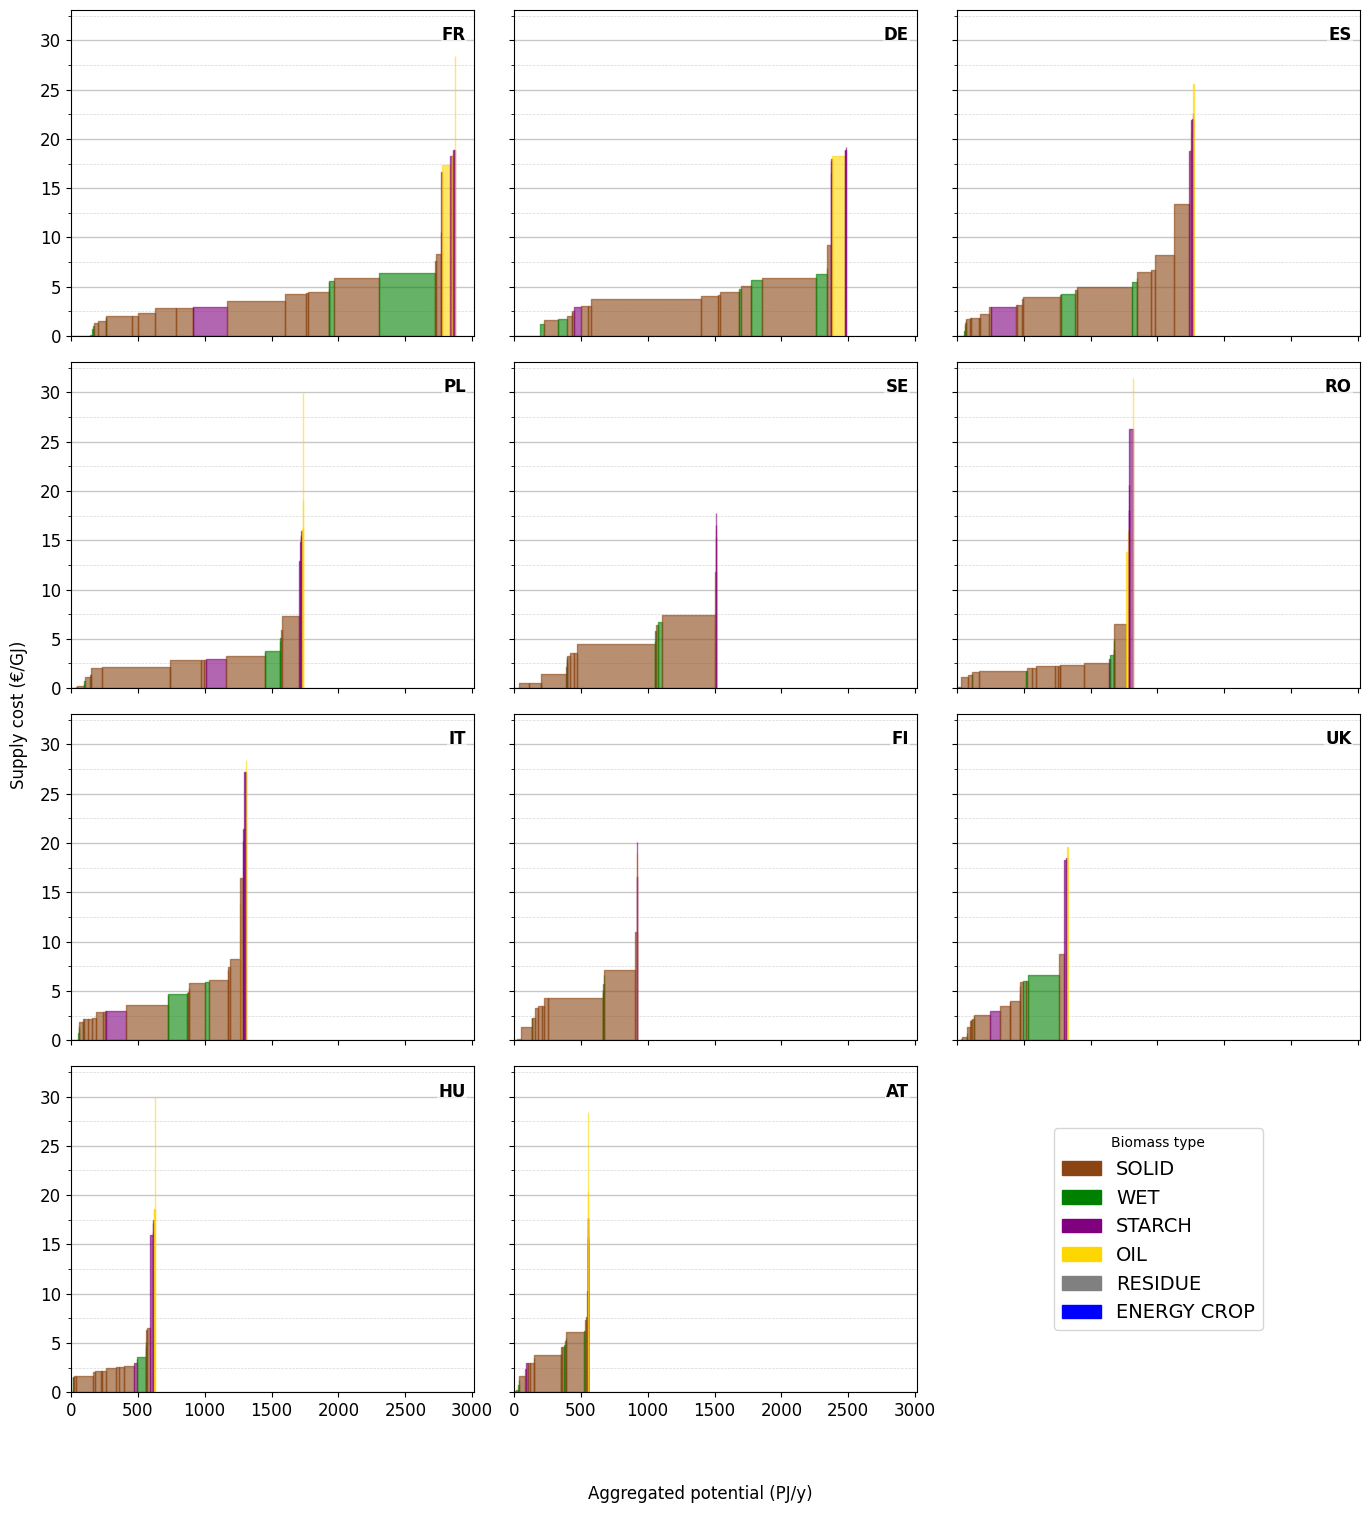

In [8]:
fig_rect, axes_rect = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*4))
axes_rect = axes_rect.flatten()

for i, (pays, meta) in enumerate(valid_sheets.items()):
    ax = axes_rect[i]
    df = meta['df'].copy()
    cost_col = meta['cost_col']
    qty_col = meta['qty_col']
    type_col = meta['type_col']

    df = df.sort_values(by=[cost_col] + ([type_col] if type_col else [])).reset_index(drop=True)
    df['Q_start'] = df[qty_col].cumsum().shift(fill_value=0)
    df['Q_end'] = df[qty_col].cumsum()

    ax.set_axisbelow(True)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
    ax.grid(which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.grid(which='major', axis='y', linestyle='-', linewidth=1, alpha=0.7)

    for _, row in df.iterrows():
        tval = row[type_col] if type_col else 'ALL'
        ax.fill_betweenx([0, row[cost_col]], x1=row['Q_start'], x2=row['Q_end'],
                         color=colors.get(tval, 'grey'), alpha=0.6, step='post')

    ax.set_xlim(0, Q_max*1.05)
    ax.set_ylim(0, Prix_max*1.05)
    ax.tick_params(axis='both', labelsize=12)
    # nom du pays dans la zone graphique (coin haut droit)
    ax.text(0.98, 0.95, pays, ha='right', va='top', transform=ax.transAxes,
            fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

    if i % ncols != 0: ax.set_yticklabels([])
    if i < ncols*(nrows-1): ax.set_xticklabels([])

# garder exactement une case vide (celle juste après les pays)
empty_idx = len(valid_sheets)

for j in range(len(valid_sheets), len(axes_rect)):
    if j == empty_idx:
        axes_rect[j].axis('off')  # on garde l'axe pour y mettre la légende
    else:
        fig_rect.delaxes(axes_rect[j])

# légende centrée dans la case vide
empty_ax = axes_rect[empty_idx]
empty_ax.legend(
    handles=[mpatches.Patch(color=colors[k], label=k) for k in colors.keys()],
    title='Biomass type',
    fontsize=14,
    loc='center'
)

fig_rect.text(0.5, 0.01, 'Aggregated potential (PJ/y)', ha='center', fontsize=12)
fig_rect.text(0.04, 0.5, 'Supply cost (€/GJ)', va='center', rotation='vertical', fontsize=12)
plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.show()


### GHG curves by biomass category and country

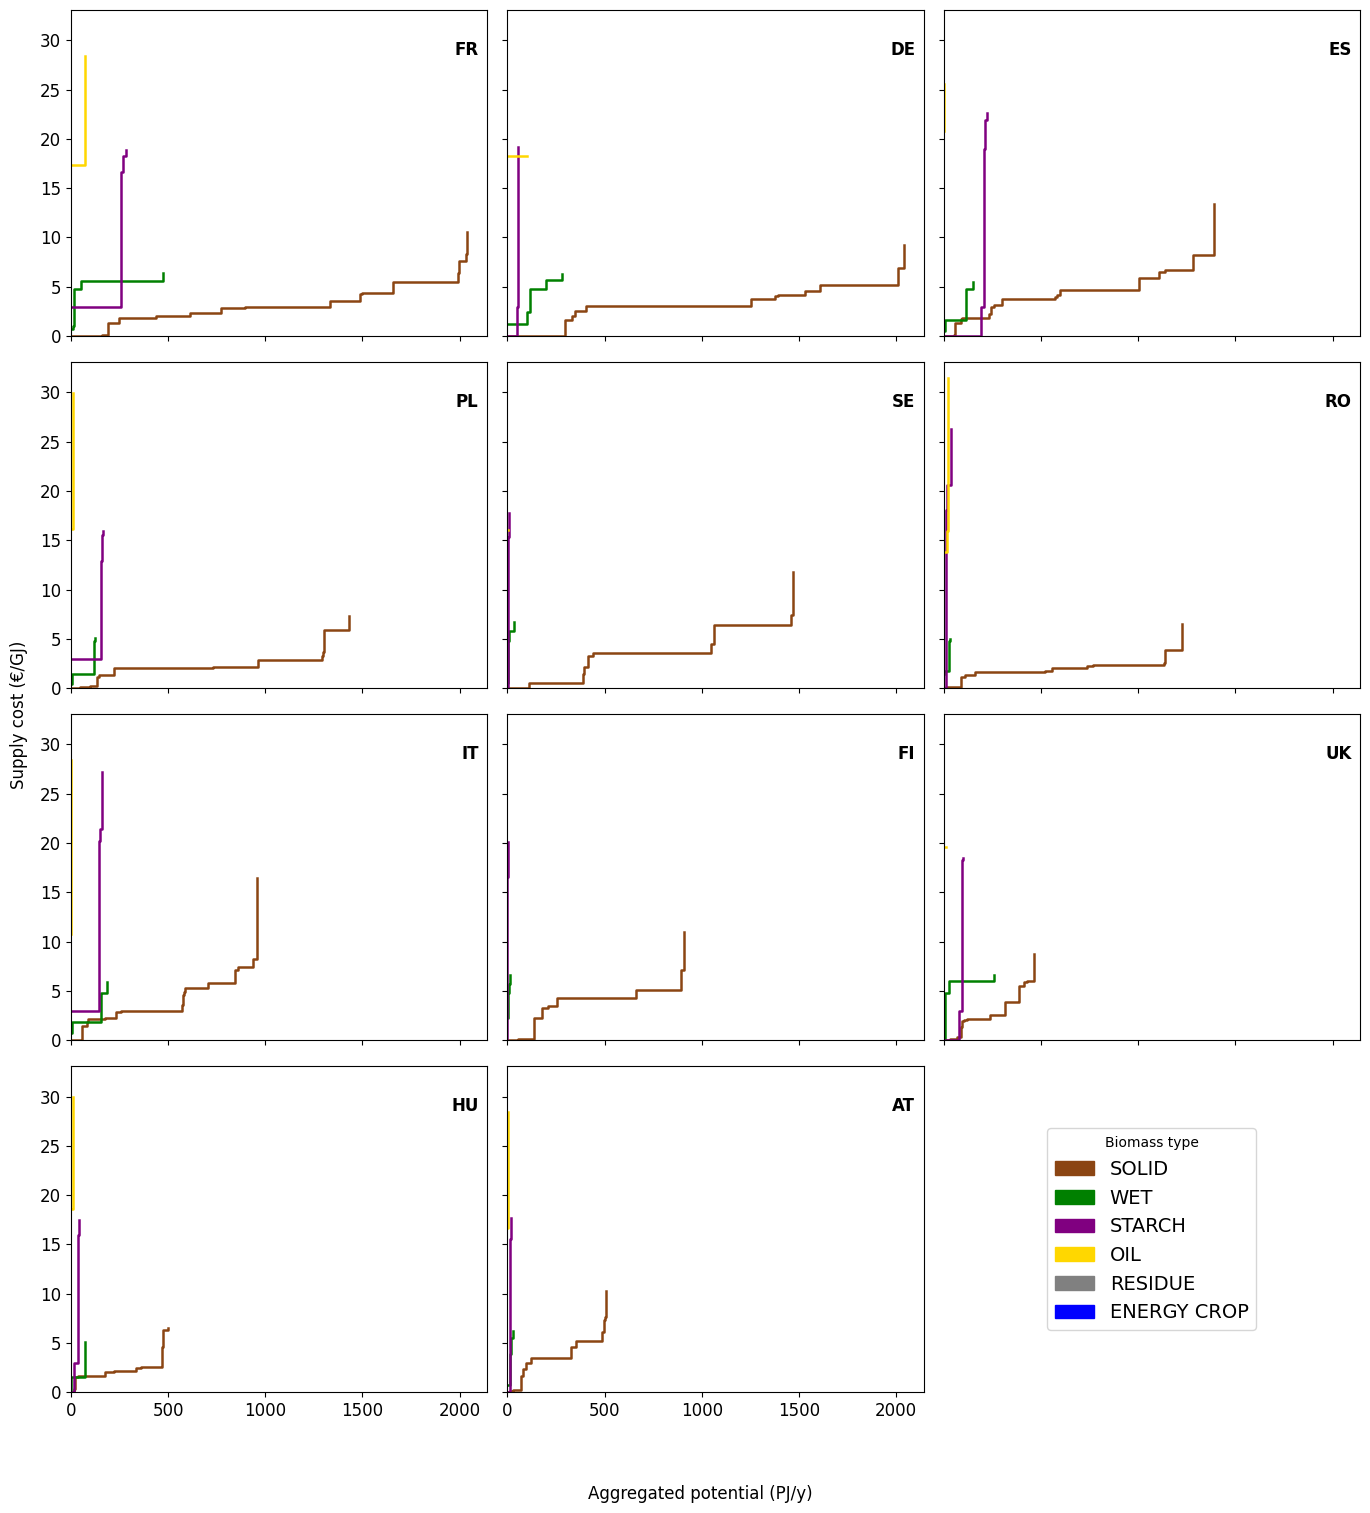

In [9]:
# --- calcul Q_max pour l'échelle X commune ---
Q_max = max(
    meta['df'].loc[meta['df'][meta['type_col']] == 'SOLID', meta['qty_col']].sum()
    for meta in valid_sheets.values()
)


fig_step, axes_step = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*4))
axes_step = axes_step.flatten()

for i, (pays, meta) in enumerate(valid_sheets.items()):
    ax = axes_step[i]
    df = meta['df'].copy()
    cost_col = meta['cost_col']
    qty_col = meta['qty_col']
    type_col = meta['type_col']

    types_list = df[type_col].unique() if type_col else ['ALL']
    for t in types_list:
        df_t = df[df[type_col] == t].sort_values(cost_col) if type_col else df.sort_values(cost_col)
        df_t = df_t[df_t[qty_col] > 0]
        if df_t.empty:
            continue

        q_cum = df_t[qty_col].cumsum()
        prix = df_t[cost_col]
        q_points = [0] + q_cum.tolist()
        prix_points = [prix.iloc[0]] + prix.tolist()
        ax.step(q_points, prix_points, where='post', color=colors.get(t, 'grey'), linewidth=1.8)

    ax.set_xlim(0, Q_max * 1.05)
    ax.set_ylim(0, Prix_max * 1.05)
    ax.tick_params(axis='both', labelsize=12)
    ax.text(0.98, 0.85, pays, ha='right', va='bottom', transform=ax.transAxes,
            fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

    if i % ncols != 0: ax.set_yticklabels([])
    if i < ncols*(nrows-1): ax.set_xticklabels([])

# garder exactement une case vide (celle juste après les pays)
empty_idx = len(valid_sheets)

for j in range(len(valid_sheets), len(axes_step)):
    if j == empty_idx:
        axes_step[j].axis('off')  # on garde l'axe pour y mettre la légende
    else:
        fig_step.delaxes(axes_step[j])

# légende centrée dans la case vide
empty_ax = axes_step[empty_idx]
empty_ax.legend(
    handles=[mpatches.Patch(color=colors[k], label=k) for k in colors.keys()],
    title='Biomass type',
    fontsize=14,
    loc='center'
)

fig_step.text(0.5, 0.01, 'Aggregated potential (PJ/y)', ha='center', fontsize=12)
fig_step.text(0.04, 0.5, 'Supply cost (€/GJ)', va='center', rotation='vertical', fontsize=12)
plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.show()


### Supply cost curve (EU) of SOLID biomass by type (ENERGY CROP, RESIDUE)

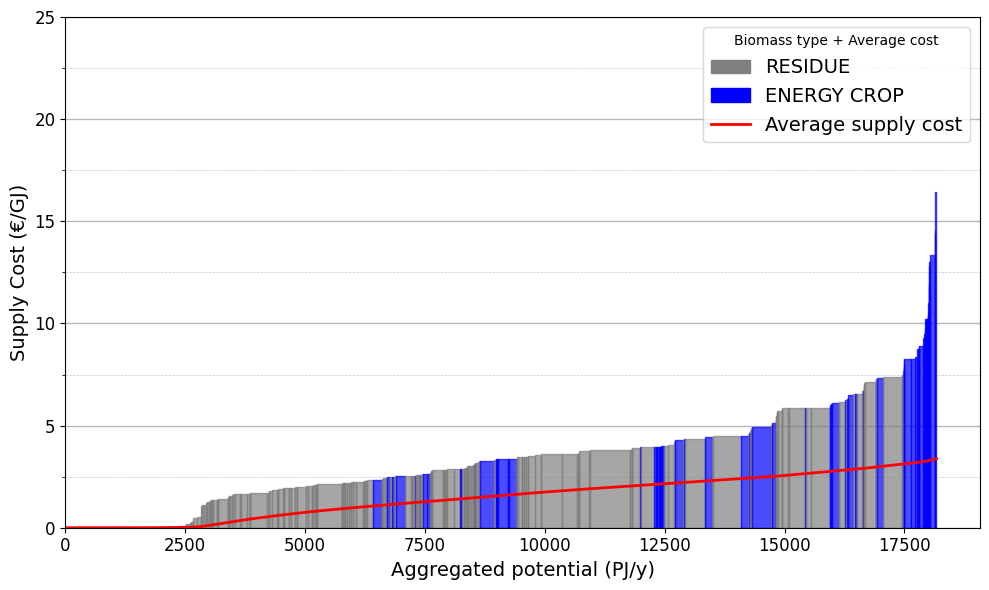

In [10]:
df = pd.read_excel(excel_file,sheet_name=sheet)


df = df[df["Category"] == "SOLID"].copy()


df = df.sort_values(by=["Cost (€/GJ)", "Type"]).reset_index(drop=True)
df["Q_start"] = df["Potential (PJ)"].cumsum().shift(fill_value=0)
df["Q_end"] = df["Potential (PJ)"].cumsum()


# --- 5) Tracer la courbe d'offre avec rectangles pleins + courbe du coût moyen ---
fig, ax = plt.subplots(figsize=(10, 6))

# Rectangles
for _, row in df.iterrows():
    ax.fill_betweenx(y=[0, row["Cost (€/GJ)"]],
                     x1=row["Q_start"], x2=row["Q_end"],
                     color=colors.get(row["Type"], "grey"), alpha=0.7, step="post")

# --- Calcul du coût moyen cumulé ---
df["cost_x_potential"] = df["Cost (€/GJ)"] * df["Potential (PJ)"]
df["cumulative_cost"] = df["cost_x_potential"].cumsum()
df["cumulative_potential"] = df["Potential (PJ)"].cumsum()
df["average_cost"] = df["cumulative_cost"] / df["cumulative_potential"]

# Tracer la courbe de coût moyen (ligne rouge épaisse)
ax.plot(df["cumulative_potential"], df["average_cost"],
        color="red", linewidth=2, label="Average supply cost")

# --- Placer la grille en arrière-plan ---
ax.set_axisbelow(True)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
ax.grid(which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
ax.grid(which='major', axis='y', linestyle='-', linewidth=1, alpha=0.9)

# --- Légende mise à jour ---
patches = [mpatches.Patch(color=colors[t], label=t) for t in df['Type'].dropna().astype(str).unique()]
legend_handles = patches + [plt.Line2D([0], [0], color='red', lw=2, label='Average supply cost')]
ax.legend(handles=legend_handles, title='Biomass type + Average cost',fontsize=14)

# --- Limites pour partir de (0,0) ---
ax.set_xlim(left=0)
ax.set_ylim(0, 25)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Aggregated potential (PJ/y)", fontsize=14)
ax.set_ylabel("Supply Cost (€/GJ)", fontsize=14)
#ax.set_title("SOLID biomass supply cost curve - EU 28 (cumulative)")
plt.tight_layout()
plt.show()

### GHG curve (EU) of SOLID biomass by type (ENERGY CROP, RESIDUE)

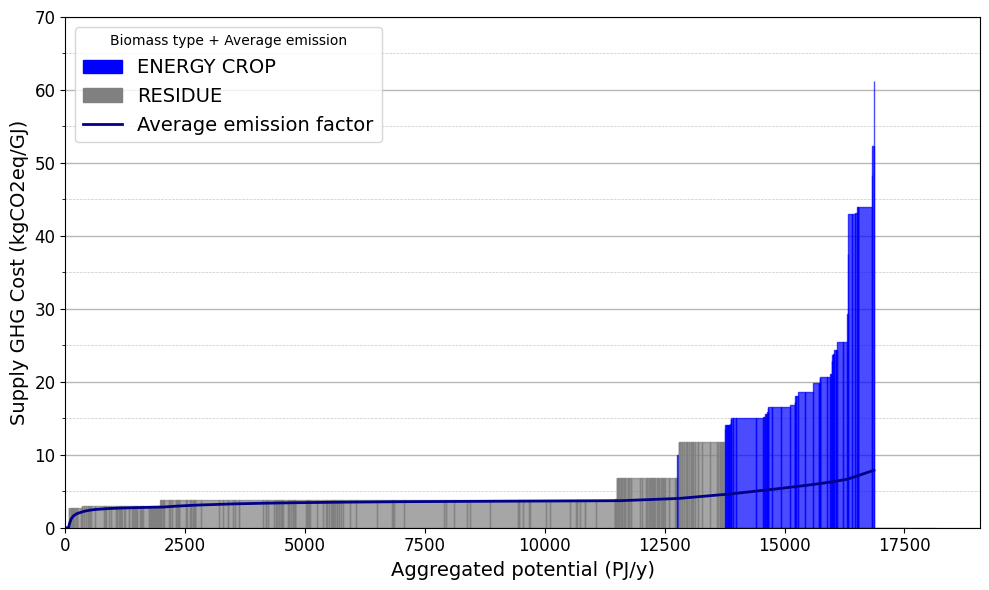

In [11]:
df = df.sort_values(by=["GHG (kgCO2eq/GJ)", "Type"]).reset_index(drop=True)
df["Q_start"] = df["Potential (PJ)"].cumsum().shift(fill_value=0)
df["Q_end"] = df["Potential (PJ)"].cumsum()

fig, ax = plt.subplots(figsize=(10, 6))

# --- Rectangles pleins ---
for _, row in df.iterrows():
    ax.fill_betweenx(y=[0, row["GHG (kgCO2eq/GJ)"]],
                     x1=row["Q_start"], x2=row["Q_end"],
                     color=colors.get(row["Type"], "grey"), alpha=0.7, step="post")

# --- Calcul du facteur d'émission moyen cumulatif ---
df["emission_x_potential"] = df["GHG (kgCO2eq/GJ)"] * df["Potential (PJ)"]
df["cumulative_emissions"] = df["emission_x_potential"].cumsum()
df["cumulative_potential"] = df["Potential (PJ)"].cumsum()
df["average_emission"] = df["cumulative_emissions"] / df["cumulative_potential"]

# Tracer la courbe de facteur d'émission moyen (ligne bleu foncé)
ax.plot(df["cumulative_potential"], df["average_emission"],
        color="darkblue", linewidth=2, label="Average emission factor")

# --- Grille et axes ---
ax.set_axisbelow(True)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
ax.grid(which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
ax.grid(which='major', axis='y', linestyle='-', linewidth=1, alpha=0.9)

# --- Légende mise à jour ---
patches = [mpatches.Patch(color=colors[t], label=t) for t in df['Type'].dropna().astype(str).unique()]
legend_handles = patches + [plt.Line2D([0], [0], color='darkblue', lw=2, label='Average emission factor')]
ax.legend(handles=legend_handles, title='Biomass type + Average emission', fontsize=14)

# --- Limites cohérentes ---
ax.set_xlim(left=0)
ax.set_ylim(0, 70)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Aggregated potential (PJ/y)", fontsize=14)
ax.set_ylabel("Supply GHG Cost (kgCO2eq/GJ)", fontsize=14)
#ax.set_title("Biomass GHG supply cost curve - EU 28 (cumulative)")
plt.tight_layout()
plt.show()

### Biomass potentials according different ENSPRESO scenarios

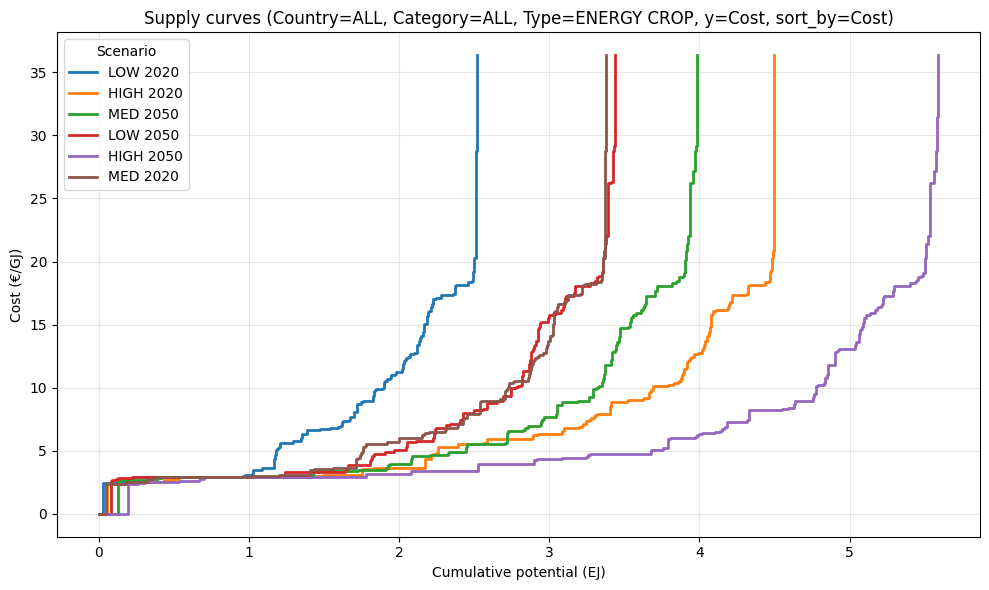

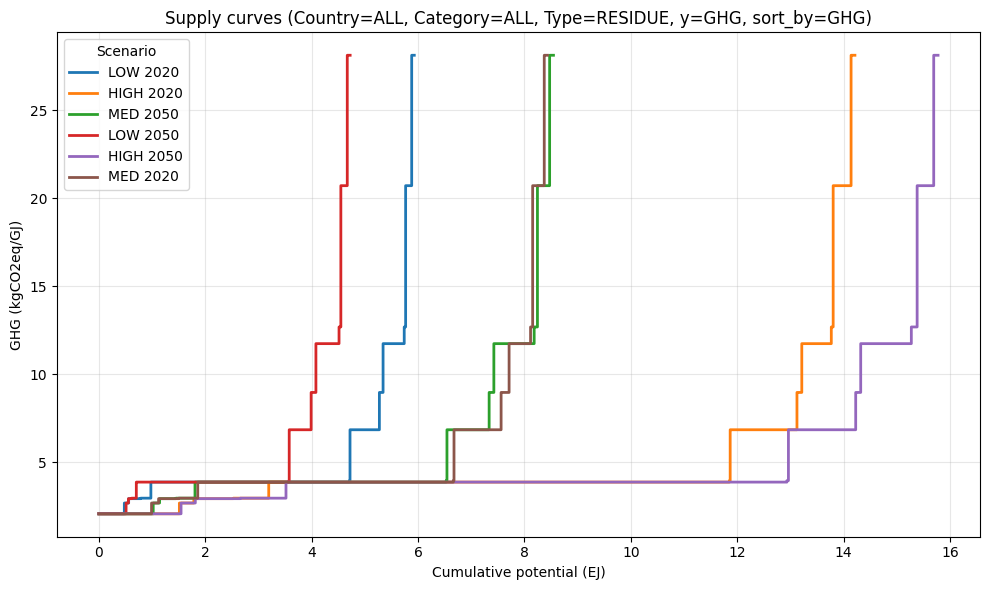

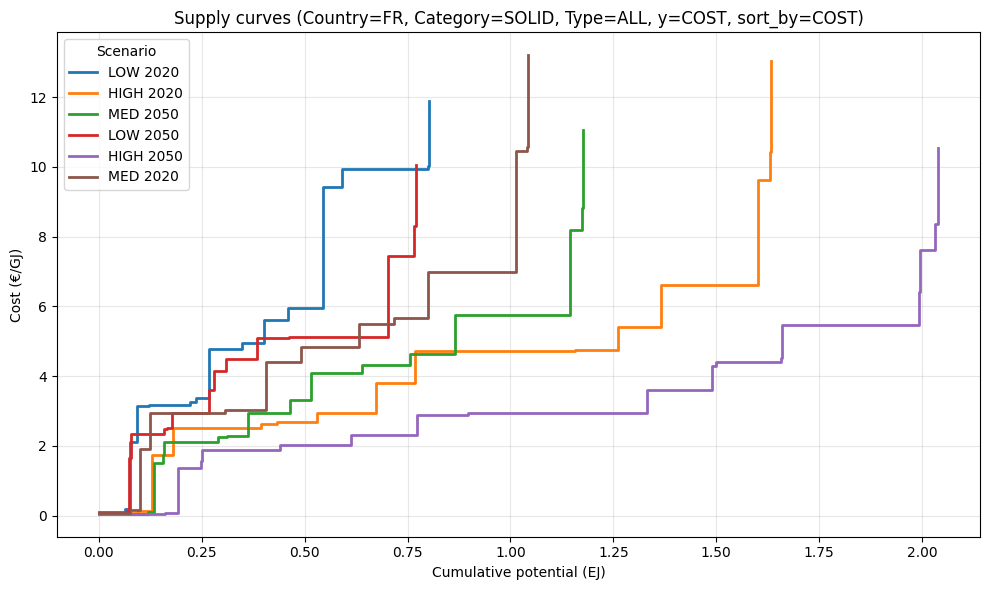

In [12]:
DATA_PATH = "ENSPRESO_supply_curves_NUTS0.xlsx"

xl = pd.ExcelFile(DATA_PATH)
scenario_dfs = {
    sheet.replace(" NUTS0", ""): pd.read_excel(DATA_PATH, sheet_name=sheet)
    for sheet in xl.sheet_names
}

COST_COL = "Cost (€/GJ)"
GHG_COL  = "GHG (kgCO2eq/GJ)"

def build_curve(
    df,
    category="ALL",
    type_="ALL",
    country="ALL",
    y_col=GHG_COL,
    sort_col=GHG_COL
):
    d = df.copy()

    cat_col     = "Category"
    type_col    = "Type"
    country_col = "NUTS0"   

    # Normalisation labels
    if cat_col in d.columns:
        d[cat_col] = d[cat_col].astype(str).str.strip()
    if type_col in d.columns:
        d[type_col] = d[type_col].astype(str).str.strip().str.upper()
    if country_col in d.columns:
        d[country_col] = d[country_col].astype(str).str.strip().str.upper()

    # Filtres
    if category != "ALL" and cat_col in d.columns:
        d = d[d[cat_col] == category]

    if type_ != "ALL" and type_col in d.columns:
        d = d[d[type_col] == type_.strip().upper()]

    if country != "ALL" and country_col in d.columns:
        d = d[d[country_col] == country.strip().upper()]

    # Force numeric
    for col in [COST_COL, GHG_COL, "Potential (PJ)"]:
        if col in d.columns:
            d[col] = pd.to_numeric(d[col], errors="coerce")

    # Nettoyage
    need = ["Potential (PJ)", y_col, sort_col]
    for col in need:
        if col not in d.columns:
            raise ValueError(f"Colonne manquante: {col}")

    d = d.dropna(subset=need)
    d = d[d["Potential (PJ)"] > 0]

    # Tri
    d = d.sort_values(sort_col, ascending=True).reset_index(drop=True)

    # Cumul
    d["cum_PJ"] = d["Potential (PJ)"].cumsum()
    d["cum_EJ"] = d["cum_PJ"] / 1000.0

    return d


def plot_eu_curves(
    category="ALL",
    type_="ALL",
    country="ALL",
    y="GHG",
    sort_by="GHG",
    x_unit="EJ"
):
    y_col    = GHG_COL if y.upper() == "GHG" else COST_COL
    sort_col = GHG_COL if sort_by.upper() == "GHG" else COST_COL

    plt.figure(figsize=(10, 6))

    for scen, df in scenario_dfs.items():
        curve = build_curve(
            df,
            category=category,
            type_=type_,
            country=country,
            y_col=y_col,
            sort_col=sort_col
        )
        if curve.empty:
            continue

        x = curve["cum_EJ"].to_numpy() if x_unit == "EJ" else curve["cum_PJ"].to_numpy()
        yv = curve[y_col].to_numpy()

        plt.step(
            np.r_[0.0, x],
            np.r_[yv[0], yv],
            where="post",
            linewidth=2,
            label=scen
        )

    plt.xlabel(f"Cumulative potential ({x_unit})")
    plt.ylabel(y_col)
    plt.title(
        f"Supply curves "
        f"(Country={country}, Category={category}, Type={type_}, "
        f"y={y}, sort_by={sort_by})"
    )
    plt.grid(True, alpha=0.3)
    plt.legend(title="Scenario", frameon=True)
    plt.tight_layout()
    plt.show()



plot_eu_curves(category="ALL", type_="ENERGY CROP", y="Cost", sort_by="Cost")
plot_eu_curves(category="ALL", type_="RESIDUE", y="GHG", sort_by="GHG")
plot_eu_curves(category="SOLID", type_="ALL", country="FR", y="COST", sort_by="COST")

# I. EnergyScope FR modelling

The first objective is to include the biomass supply curves into the French version of EnergyScope, using the different biomass ENSPRESO scenarios to see the effect on the total cost of the system and on the different biomass usage pathways.

### EnergyScope FR runs with different biomass scenarios

In [13]:
import os
import sys
from pathlib import Path
import plotly.io as pio

pio.renderers.default = "browser"


# 1) Pointe vers la racine du repo EnergyScope (celle qui contient scripts/ et my_energyscope/)
PROJECT_ROOT = Path(r"C:\Users\ED281169\Documents\EnergyScope\EnergyScopeFR_Biomass_supply_curves").resolve()

# 2) Important: working directory = root du projet (car plein de chemins relatifs)
os.chdir(PROJECT_ROOT)

# 3) Ajout au PYTHONPATH pour importer my_energyscope
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import my_energyscope as es




In [14]:
def run_energyscope_from_notebook(
    config_fn="config_ref.yaml",
    case_studies_subpath=("case_studies",),
    case_study="case BIOMASS FR LOW_2050",
    biomass_enable=True,
    biomass_scenario="MED",
    biomass_year=2050,
    biomass_nuts0="FR",
    analysis_only=False,
    compute_TDs=False,
    hourly_data=True,
    layers=None,
    print_sankey=False,
    wood_cap=1e12,
    gwp_limit=10
):
    """
    Lance EnergyScope depuis Jupyter avec override biomasse + modes:
      - analysis_only=True  -> ne lance pas l'optim (lit juste les outputs existants)
      - analysis_only=False -> génère .dat + run optim + lit outputs
    """
    project_path = PROJECT_ROOT  # racine repo

    # Charger config
    config = es.load_config(config_fn=config_fn, project_path=project_path)

    # Paths / case study
    config["Working_directory"] = os.getcwd()
    config["case_studies"] = str(project_path.joinpath(*case_studies_subpath))
    config["case_study"] = case_study

    # --- Override biomasse (robuste) ---
    cfg = config.setdefault("biomass_supply_curve", {})
    cfg["xlsx_path"] = str(PROJECT_ROOT / "ENSPRESO_supply_curves_NUTS0.xlsx")
    cfg.update({
        "scenario": biomass_scenario,
        "year": int(biomass_year),
        "nuts0": biomass_nuts0,
        "enable": bool(biomass_enable),
    })
    config["biomass_supply_curve"] = cfg

    # Compat: certaines versions lisent ces clés-là
    config["biomass_scenario"] = biomass_scenario
    config["biomass_year"] = int(biomass_year)
    config["biomass_nuts0"] = biomass_nuts0
    config["biomass_enable"] = bool(biomass_enable)

    # Et si tu as une section "biomass" (fréquent)
    b = config.setdefault("biomass", {})
    b.update({
        "scenario": biomass_scenario,
        "year": int(biomass_year),
        "nuts0": biomass_nuts0,
        "enable": bool(biomass_enable),
    })
    config["biomass"] = b

    print("ENS override biomass_supply_curve:", config["biomass_supply_curve"])
    print("ENS override biomass_scenario:", config.get("biomass_scenario"))
    print("ENS override biomass:", config.get("biomass"))




    # Log file AMPL (comme ton script)
    config["ampl_options"]["log_file"] = os.path.join(
        config["case_studies"], config["case_study"], config["ampl_options"]["log_file"]
    )

    #Add wood_cap
    config["wood_cap"] = wood_cap

    # Add gwp_limit override
    if gwp_limit is not None:
        config["GWP_limit"] = float(gwp_limit)

    # Import data (modifie/charge les CSV, etc.)
    es.import_data(config)
    
    print("AFTER import_data - biomass keys:",
      config.get("biomass_supply_curve"),
      config.get("biomass_scenario"),
      config.get("biomass"))

    if compute_TDs:
        es.build_td_of_days(config)

    # Si on veut rerun le modèle (pas seulement analyse)
    if not analysis_only:
        es.print_data(config)
        es.run_es(config)

    # Lire outputs
    if layers is None:
        layers = [
            "layer_ELECTRICITY","layer_HEAT_LOW_T_DECEN","layer_HEAT_LOW_T_DHN",
            "layer_HEAT_HIGH_T","layer_AMMONIA","layer_H2","layer_LFO",
            "layer_GAS","layer_JETFUEL","layer_FT_FUEL"
        ]

    outputs = es.read_outputs(config, hourly_data=hourly_data, layers=layers)

    # Optionnel: sankey
    if print_sankey:
        out_dir = os.path.join(config["case_studies"], config["case_study"], "output", "sankey")
        os.makedirs(out_dir, exist_ok=True)

        fig_energy = es.Sankey_plot(outputs["year_balance"], outputs["sto_year"])
        fig_energy.update_layout(width=3000, height=1800, font=dict(size=22, color="black"))
        fig_energy.show()

        fig_carbon = es.Sankey_carbon(outputs["year_balance"], outputs["gwp_breakdown"])
        fig_carbon.update_layout(width=2500, height=1500, font=dict(size=22, color="black"))
        fig_carbon.show()

    return config, outputs



This script allows to test biomass assumptions across the different ENSPRESO scenarios and runs the Energyscope FR model

In [15]:
config, outputs = run_energyscope_from_notebook(
    biomass_scenario="LOW",
    case_study="case BIOMASS FR LOW_2050",
    biomass_year=2050,
    analysis_only=False,   # True = analyse seule
    print_sankey=True
)



[INFO    ] (import_data): Importing data files from C:\Users\ED281169\Documents\EnergyScope\EnergyScopeFR_Biomass_supply_curves\data
[INFO    ] (apply_enspreso): ENSPRESO enabled: resources updated from LOW 2050 NUTS0, growth techs blocked
[INFO    ] (print_data): Printing ESTD_data.dat
C:\Users\ED281169\Documents\EnergyScope\EnergyScopeFR_Biomass_supply_curves\my_energyscope\preprocessing\es_pre\es_write_energy_model_data.py:220: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Infinity' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.

C:\Users\ED281169\Documents\EnergyScope\EnergyScopeFR_Biomass_supply_curves\my_energyscope\preprocessing\es_pre\es_write_energy_model_data.py:222: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Infinity' has dtype incompatible with float64, please expl

ENS override biomass_supply_curve: {'enable': True, 'xlsx_path': 'C:\\Users\\ED281169\\Documents\\EnergyScope\\EnergyScopeFR_Biomass_supply_curves\\ENSPRESO_supply_curves_NUTS0.xlsx', 'scenario': 'LOW', 'year': 2050, 'nuts0': 'FR', 'solid_cap_gwh': 'None'}
ENS override biomass_scenario: LOW
ENS override biomass: {'scenario': 'LOW', 'year': 2050, 'nuts0': 'FR', 'enable': True}
AFTER import_data - biomass keys: {'enable': True, 'xlsx_path': 'C:\\Users\\ED281169\\Documents\\EnergyScope\\EnergyScopeFR_Biomass_supply_curves\\ENSPRESO_supply_curves_NUTS0.xlsx', 'scenario': 'LOW', 'year': 2050, 'nuts0': 'FR', 'solid_cap_gwh': 'None'} LOW {'scenario': 'LOW', 'year': 2050, 'nuts0': 'FR', 'enable': True}
           Electricity (%_elec)  Space Heating (%_sh)  \
{PERIODS}                                               
1                      0.000118              0.000243   
2                      0.000109              0.000248   
3                      0.000107              0.000246   
4          

SystemExit: 1

C:\Users\ED281169\AppData\Roaming\Python\Python312\site-packages\IPython\core\interactiveshell.py:3709: UserWarning:

To exit: use 'exit', 'quit', or Ctrl-D.



In [ ]:


total_cost = outputs["cost_breakdown"].sum().sum()
print(f"Coût total du système : {total_cost:.0f} G€")


## What merit order for biomass in the French Energy System ?

In this section, we want to build the merit order of biomass feedstocks for France, depending on their costs and environmental performance for the French Energy system. To do so, we vary the maximum traded volume of SOLID biomass category from zero to maximum potential.

In [31]:
#Test limite de convergence --> a priori un peu en-dessous de 100 TWh/an pour HIGH_2050, 115 TWh/an pour MED_2050, 135 TWh/an pour LOW_2050
config, outputs = run_energyscope_from_notebook(
    wood_cap=110000,
    analysis_only=False,
    case_studies_subpath=("case_studies_HIGH",),
    case_study="test_case",                  # <-- clé
    biomass_scenario="HIGH",
    biomass_year=2050,
    print_sankey=False
            )

TypeError: unsupported operand type(s) for /: 'str' and 'str'

In [ ]:

total_cost = outputs["cost_breakdown"].sum().sum()
print(f"Coût total du système : {total_cost:.0f} G€")

Coût total du système : 286796 G€


#### Building the French "merit order" of biomass: Evolution of total cost (M€/y), biomass feedstocks used and uses depending of biomass availability (GWh/y), for the three 2050 ENSPRESO scenarios (HIGH, MED, LOW)

This first script selects the different feedstocks of solid biomass and the different processes using solid biomass. Then it defines functions to compute the total cost of the system, to read the year balance between feedstocks and uses and to read the contribution of each feedstock and each use.

In [ ]:
import os
import pandas as pd
import numpy as np

SEGMENTS_WOOD = [
    "OLIVE_PITS","APPLES","CEREALSTRAW","CHERRIES","MAIZESTRAW","OLIVES","OSR","RICESTRAW",
    "VINEYARDS","MISCANTHUS","SWITCHGRASS","WILLOW","POPLAR","CP_RES","FUELWOOD_RES",
    "LANDSCAPECARE","MSW","FUELWOODRW","OTHERSECRESID","SAWDUST","CP_RW"
]

WOOD_TECHS = [
    "IND_COGEN_WOOD","IND_BOILER_WOOD","DHN_COGEN_WOOD","DHN_BOILER_WOOD","DEC_BOILER_WOOD",
    "H2_BIOMASS","WOOD_TO_METHANE","E_WOOD_TO_METHANE","PYROLYSIS_TO_LFO","PYROLYSIS_TO_FUELS",
    "E_WOOD_TO_FT","WOOD_TO_FT","WOOD_TO_METHANOL","E_WOOD_TO_METHANOL","BIOMASS_TO_HVC", "BIOMASS_SEQUESTRATION"
]


def read_total_cost(cost_breakdown_path: str) -> float:
    df = pd.read_csv(cost_breakdown_path, sep="\t")
    return float(df.select_dtypes(include="number").to_numpy().sum())



def read_year_balance(year_balance_path: str) -> pd.DataFrame:
    df = pd.read_csv(year_balance_path, sep=r"\s+", engine="python")
    # Normalise first column name
    if df.columns[0] != "Tech":
        df = df.rename(columns={df.columns[0]: "Tech"})
    # Ensure WOOD exists
    if "WOOD" not in df.columns:
        raise ValueError(f"'WOOD' column not found in {year_balance_path}. Columns: {list(df.columns)}")
    df["Tech"] = df["Tech"].astype(str)
    df["WOOD"] = pd.to_numeric(df["WOOD"], errors="coerce").fillna(0.0)
    return df


def extract_segments_and_uses_from_year_balance(df_yb: pd.DataFrame,
                                               segments: list[str],
                                               techs: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    # Segments: injection into WOOD (typically positive)
    df_seg = df_yb[df_yb["Tech"].isin(segments)][["Tech", "WOOD"]].copy()
    df_seg = df_seg.rename(columns={"Tech": "segment", "WOOD": "wood_injected_GWh"})
    df_seg["wood_injected_GWh"] = df_seg["wood_injected_GWh"].clip(lower=0.0)

    # Tech uses: consumption from WOOD (typically negative -> consumed = -value)
    df_use = df_yb[df_yb["Tech"].isin(techs)][["Tech", "WOOD"]].copy()
    df_use = df_use.rename(columns={"Tech": "technology", "WOOD": "wood_balance_GWh"})
    df_use["wood_consumed_GWh"] = (-df_use["wood_balance_GWh"]).clip(lower=0.0)
    df_use = df_use.drop(columns=["wood_balance_GWh"])

    # Fill missing with 0 for robustness
    missing_seg = [s for s in segments if s not in set(df_seg["segment"])]
    if missing_seg:
        df_seg = pd.concat([df_seg, pd.DataFrame({"segment": missing_seg, "wood_injected_GWh": 0.0})],
                           ignore_index=True)

    missing_tech = [t for t in techs if t not in set(df_use["technology"])]
    if missing_tech:
        df_use = pd.concat([df_use, pd.DataFrame({"technology": missing_tech, "wood_consumed_GWh": 0.0})],
                           ignore_index=True)

    return (df_seg.sort_values("segment").reset_index(drop=True),
            df_use.sort_values("technology").reset_index(drop=True))


def extract_run_metrics(output_dir: str,
                        run_id: int,
                        wood_cap: float,
                        segments: list[str] = SEGMENTS_WOOD,
                        techs: list[str] = WOOD_TECHS,
                        year_balance_filename: str = "year_balance.txt") -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    cost_path = os.path.join(output_dir, "cost_breakdown.txt")
    yb_path = os.path.join(output_dir, year_balance_filename)

    total_cost = read_total_cost(cost_path)
    df_yb = read_year_balance(yb_path)
    df_seg, df_use = extract_segments_and_uses_from_year_balance(df_yb, segments, techs)

    # Optional sanity check: injected ≈ consumed (can differ if other WOOD rows exist)
    injected = df_seg["wood_injected_GWh"].sum()
    consumed = df_use["wood_consumed_GWh"].sum()

    df_run = pd.DataFrame([{
        "run_id": run_id,
        "wood_cap": float(wood_cap),
        "total_cost": total_cost,
        "wood_injected_GWh": injected,
        "wood_consumed_GWh": consumed,
        "wood_balance_gap_GWh": injected - consumed,
        "output_dir": output_dir
    }])

    df_seg.insert(0, "run_id", run_id)
    df_seg.insert(1, "wood_cap", float(wood_cap))

    df_use.insert(0, "run_id", run_id)
    df_use.insert(1, "wood_cap", float(wood_cap))

    return df_run, df_seg, df_use


def extract_all_runs(wood_caps: np.ndarray,
                     output_dirs: list[str],
                     year_balance_filename: str = "year_balance.txt"):
    if len(output_dirs) != len(wood_caps):
        raise ValueError("output_dirs must have same length as wood_caps")

    runs, segs, uses = [], [], []
    for i, (wc, outdir) in enumerate(zip(wood_caps, output_dirs)):
        df_run, df_seg, df_use = extract_run_metrics(
            output_dir=outdir,
            run_id=i,
            wood_cap=float(wc),
            year_balance_filename=year_balance_filename
        )
        runs.append(df_run)
        segs.append(df_seg)
        uses.append(df_use)

    return (pd.concat(runs, ignore_index=True),
            pd.concat(segs, ignore_index=True),
            pd.concat(uses, ignore_index=True))



This second script runs the EnergyScope_FR model for different biomass availability assumptions [100 TWh - 600 TWh] and different 2050 ENSPRESO scenarios.

In [ ]:
wood_caps = np.linspace(100000, 600000, 101)

output_dirs = []
results_runs, results_segments, results_uses = [], [], []

BASE_CASE = "case SOLID_BIOMASS_capacity"  # ton template

for i, wc in enumerate(wood_caps):
    #Cas HIGH
    case_name = f"{BASE_CASE}_HIGH__wc_{int(wc)}"   # nom unique
    config, outputs = run_energyscope_from_notebook(
        wood_cap=wc,
        analysis_only=False,
        case_studies_subpath=("case_studies_HIGH",),
        case_study=case_name,                  # <-- clé
        biomass_scenario="HIGH",
        biomass_year=2050,
        print_sankey=False
    )
    
    outdir = os.path.join(config["case_studies"], config["case_study"], "output")
    output_dirs.append(outdir)

    # --- extraction immédiate depuis year_balance + cost_breakdown ---
    df_run, df_seg, df_use = extract_run_metrics(
        output_dir=outdir,
        run_id=i,
        wood_cap=wc,
        year_balance_filename="year_balance.txt"
    )
    results_runs.append(df_run)
    results_segments.append(df_seg)
    results_uses.append(df_use)

    if wc > 115000 :
        if wc < 351000 :
            #Cas MED
            case_name = f"{BASE_CASE}_MED__wc_{int(wc)}"   # nom unique
            config, outputs = run_energyscope_from_notebook(
                wood_cap=wc,
                analysis_only=False,
                case_studies_subpath=("case_studies_MED",),
                case_study=case_name,                  # <-- clé
                biomass_scenario="MED",
                biomass_year=2050,
                print_sankey=False
            )
            
            outdir = os.path.join(config["case_studies"], config["case_study"], "output")
            output_dirs.append(outdir)

            # --- extraction immédiate depuis year_balance + cost_breakdown ---
            df_run, df_seg, df_use = extract_run_metrics(
                output_dir=outdir,
                run_id=i,
                wood_cap=wc,
                year_balance_filename="year_balance.txt"
            )
            results_runs.append(df_run)
            results_segments.append(df_seg)
            results_uses.append(df_use)

        if wc > 131000 :
            if wc < 230000 :
                #Cas LOW
                case_name = f"{BASE_CASE}_LOW__wc_{int(wc)}"   # nom unique
                config, outputs = run_energyscope_from_notebook(
                    wood_cap=wc,
                    analysis_only=False,
                    case_studies_subpath=("case_studies_LOW",),
                    case_study=case_name,                  # <-- clé
                    biomass_scenario="LOW",
                    biomass_year=2050,
                    print_sankey=False
                )
                
                outdir = os.path.join(config["case_studies"], config["case_study"], "output")
                output_dirs.append(outdir)

                # --- extraction immédiate depuis year_balance + cost_breakdown ---
                df_run, df_seg, df_use = extract_run_metrics(
                    output_dir=outdir,
                    run_id=i,
                    wood_cap=wc,
                    year_balance_filename="year_balance.txt"
                )
                results_runs.append(df_run)
                results_segments.append(df_seg)
                results_uses.append(df_use)

df_runs = pd.concat(results_runs, ignore_index=True)
df_segments = pd.concat(results_segments, ignore_index=True)
df_uses = pd.concat(results_uses, ignore_index=True)



In [ ]:
from pathlib import Path

BASE = Path(
    r"C:\Users\ED281169\Documents\EnergyScope"
    r"\EnergyScopeFR_Biomass_supply_curves"
)

import pandas as pd
from pathlib import Path

output_file = BASE / "extract_runs_segments_uses.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df_runs.to_excel(writer, sheet_name="runs", index=False)
    df_segments.to_excel(writer, sheet_name="segments", index=False)
    df_uses.to_excel(writer, sheet_name="uses", index=False)

print(f"Excel écrit ici : {output_file}")


Excel écrit ici : C:\Users\ED281169\Documents\EnergyScope\EnergyScopeFR_Biomass_supply_curves\extract_runs_segments_uses.xlsx


#### This section allows to compute the marginal carbon cost of the system (€/tCO2) for different biomass availability

In [33]:
config, outputs = run_energyscope_from_notebook(
    biomass_scenario="HIGH",
    case_study="case BIOMASS FR HIGH_2050_dual_carbon_2",
    biomass_year=2050,
    analysis_only=False,   # True = analyse seule
    print_sankey=True,
    gwp_limit=11,
    wood_cap=565000
)


[INFO    ] (import_data): Importing data files from C:\Users\ED281169\Documents\EnergyScope\EnergyScopeFR_Biomass_supply_curves\data
[INFO    ] (apply_enspreso): ENSPRESO enabled: resources updated from HIGH 2050 NUTS0, growth techs blocked
[INFO    ] (print_data): Printing ESTD_data.dat


ENS override biomass_supply_curve: {'enable': True, 'xlsx_path': 'C:\\Users\\ED281169\\Documents\\EnergyScope\\EnergyScopeFR_Biomass_supply_curves\\ENSPRESO_supply_curves_NUTS0.xlsx', 'scenario': 'HIGH', 'year': 2050, 'nuts0': 'FR', 'solid_cap_gwh': 'None'}
ENS override biomass_scenario: HIGH
ENS override biomass: {'scenario': 'HIGH', 'year': 2050, 'nuts0': 'FR', 'enable': True}
AFTER import_data - biomass keys: {'enable': True, 'xlsx_path': 'C:\\Users\\ED281169\\Documents\\EnergyScope\\EnergyScopeFR_Biomass_supply_curves\\ENSPRESO_supply_curves_NUTS0.xlsx', 'scenario': 'HIGH', 'year': 2050, 'nuts0': 'FR', 'solid_cap_gwh': 'None'} HIGH {'scenario': 'HIGH', 'year': 2050, 'nuts0': 'FR', 'enable': True}


C:\Users\ED281169\Documents\EnergyScope\EnergyScopeFR_Biomass_supply_curves\my_energyscope\preprocessing\es_pre\es_write_energy_model_data.py:220: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Infinity' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.

C:\Users\ED281169\Documents\EnergyScope\EnergyScopeFR_Biomass_supply_curves\my_energyscope\preprocessing\es_pre\es_write_energy_model_data.py:222: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Infinity' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.

[INFO    ] (print_data): Printing ESTD_12TD.dat
[INFO    ] (run_es): Running EnergyScope


           Electricity (%_elec)  Space Heating (%_sh)  \
{PERIODS}                                               
1                      0.000118              0.000243   
2                      0.000109              0.000248   
3                      0.000107              0.000246   
4                      0.000101              0.000245   
5                      0.000093              0.000247   
...                         ...                   ...   
8756                   0.000120              0.000316   
8757                   0.000114              0.000318   
8758                   0.000107              0.000312   
8759                   0.000102              0.000316   
8760                   0.000112              0.000315   

           Passanger mobility (%_pass)  Freight mobility (%_freight)   PV  \
{PERIODS}                                                                   
1                             0.000006                      0.000114  0.0   
2                          

SystemExit: 1

C:\Users\ED281169\AppData\Roaming\Python\Python312\site-packages\IPython\core\interactiveshell.py:3709: UserWarning:

To exit: use 'exit', 'quit', or Ctrl-D.

